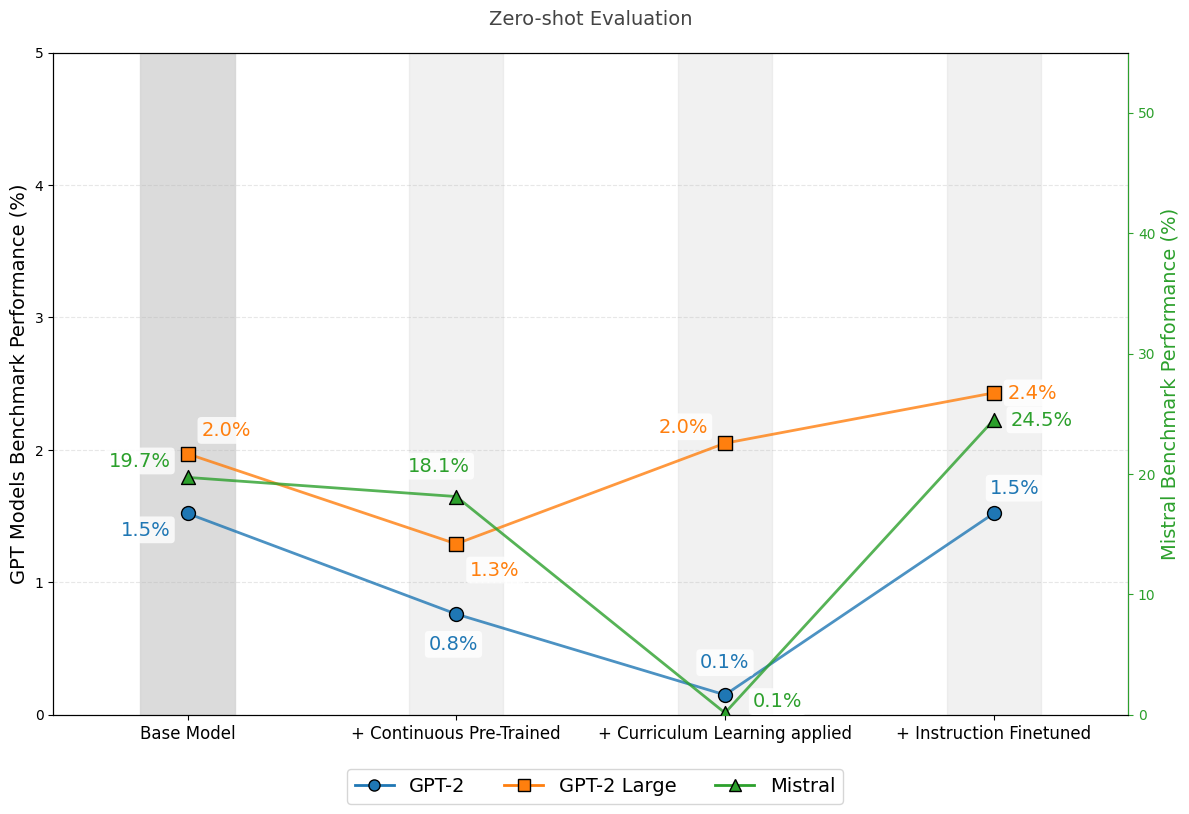

In [40]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D

# Load the data from the Excel file
# Note: Update the path to your actual file location
df = pd.read_excel('/Users/mauricebaier/Documents/Master/4th_master_thesis/_code/math-reasoning-in-language-models/data/Performances.xlsx', engine='openpyxl')

# Ensure the columns are numeric
# Using the correct column name "Zero Shot"
df['Zero Shot'] = pd.to_numeric(df['Zero Shot'], errors='coerce')

# Extract unique models and training types
models = df['Model'].unique()
training_types = df['Training Type'].unique()

# Define training type positions on x-axis
training_positions = {training: i+1 for i, training in enumerate(training_types)}

# Define colors and markers for models with better visual distinction
model_colors = {
    'GPT-2': '#1f77b4',         # Blue
    'GPT-2 Large': '#ff7f0e',   # Orange
    'Mistral': '#2ca02c'        # Green
}

model_markers = {
    'GPT-2': 'o',         # Circle
    'GPT-2 Large': 's',   # Square
    'Mistral': '^'        # Triangle
}

# Create a figure with a single plot area - slightly taller for legend space at bottom
fig, ax_left = plt.subplots(figsize=(12, 9))

# Create a right y-axis for Mistral
ax_right = ax_left.twinx()

# Set colors for axes
left_color = 'black'      # GPT models
right_color = '#2ca02c'   # Mistral - green

# Style the y-axes
ax_left.tick_params(axis='y', colors=left_color)
ax_left.spines['left'].set_color(left_color)
ax_right.tick_params(axis='y', colors=right_color)
ax_right.spines['right'].set_color(right_color)

# Create wider training "bars" instead of lines
bar_width = 0.35  # Width for bars
for training, x_pos in training_positions.items():
    # Draw wider "bars" for each training position
    # Make the "Raw" section significantly darker
    if training == 'Raw':
        alpha_value = 0.8  # Darker alpha for Base Model (Raw)
    else:
        alpha_value = 0.3  # Keep original alpha for others
        
    ax_left.add_patch(plt.Rectangle((x_pos - bar_width/2, 0), bar_width, 5, 
                              color='lightgray', alpha=alpha_value, zorder=0))

# Prepare data for connecting lines between training types for the same model
model_data = {model: {'x': [], 'y': [], 'training': []} for model in models}

# First, collect all data points
for training, x_pos in training_positions.items():
    # For each model
    for model in models:
        # Get data for this model and training combination
        data_row = df[(df['Model'] == model) & (df['Training Type'] == training)]
        
        if not data_row.empty:
            # Get Zero-shot value with correct column name
            zero_shot = data_row['Zero Shot'].iloc[0]
            
            # Store x and y for connecting lines later
            model_data[model]['x'].append(x_pos)
            model_data[model]['y'].append(zero_shot)
            model_data[model]['training'].append(training)

# Plot data and connect lines for each model
for model, data in model_data.items():
    x_values = data['x']
    y_values = data['y']
    
    # Choose appropriate axis based on model type
    if model == 'Mistral':
        ax = ax_right
    else:
        ax = ax_left
    
    # Draw connecting lines first (beneath points)
    ax.plot(x_values, y_values, color=model_colors[model], linestyle='-', 
            linewidth=2, alpha=0.8, zorder=2)
    
    # Draw points
    ax.scatter(x_values, y_values, 
              color=model_colors[model], marker=model_markers[model], 
              s=100, zorder=3, edgecolors='black', linewidth=1)
    
    # Add small labels for each data point with white background for better readability
    # Use predefined positions to avoid overlaps
    for i, (x, y) in enumerate(zip(x_values, y_values)):
        training = data['training'][i]
        
        # Custom positioning for each data point based on model and training type
        # to avoid overlaps without using external libraries
        if model == 'Mistral':
            if training == 'Raw':
                offset_x, offset_y = -12, 5
                ha, va = 'right', 'bottom'
            elif training == 'Continuous Pre-Trained':
                offset_x, offset_y = 10, 15 
                ha, va = 'right', 'bottom'
            elif training == 'Curriculum Learning':
                offset_x, offset_y = 20, 15  # RIGHT of data point, slightly lower
                ha, va = 'left', 'top'
            else:  # Instruction Finetuned
                offset_x, offset_y = 12, 0  # Just right of data point
                ha, va = 'left', 'center'
        elif model == 'GPT-2':
            if training == 'Raw':
                offset_x, offset_y = -12, -5
                ha, va = 'right', 'top'
            elif training == 'Continuous Pre-Trained':
                offset_x, offset_y = -2, -15
                ha, va = 'center', 'top'
            elif training == 'Curriculum Learning':
                offset_x, offset_y = 0, 30  # ABOVE data point with MORE distance
                ha, va = 'center', 'top'
            else:  # Instruction Finetuned
                offset_x, offset_y = 15, 25  # Just above data point
                ha, va = 'center', 'top'
        else:  # GPT-2 Large
            if training == 'Raw':
                offset_x, offset_y = 10, 10
                ha, va = 'left', 'bottom'
            elif training == 'Continuous Pre-Trained':
                offset_x, offset_y = 10, -12
                ha, va = 'left', 'top'
            elif training == 'Curriculum Learning':
                offset_x, offset_y = -12, 5  # LEFT and ABOVE data point
                ha, va = 'right', 'bottom'
            else:  # Instruction Finetuned
                offset_x, offset_y = 10, 0  # RIGHT of data point
                ha, va = 'left', 'center'
        
        # Create label with white background for better readability
        ax.annotate(
            f"{y:.1f}%", 
            xy=(x, y),
            xytext=(offset_x, offset_y),
            textcoords='offset points',
            ha=ha, va=va,
            fontsize=14,
            color=model_colors[model],
            bbox=dict(boxstyle="round,pad=0.2", fc='white', ec="none", alpha=0.8)
        )

# Set y-axis limits with some padding
ax_left.set_ylim(0, 5)      # GPT models scale (0-5%)
ax_right.set_ylim(0, 55)    # Mistral scale (0-55%)

# Modify x-axis labels: Add "+" in front except for "Raw" and change "Curriculum Learning" to "Curriculum Learning applied"
modified_labels = []
for label in training_positions.keys():
    if label == 'Raw':
        modified_labels.append("Base Model")  # Changed from "Raw" to "Base Model"
    elif label == 'Curriculum Learning':
        modified_labels.append("+ Curriculum Learning applied")
    else:
        modified_labels.append("+ " + label)

# Set x-axis labels
ax_left.set_xticks(list(training_positions.values()))
ax_left.set_xticklabels(modified_labels, fontsize=12, rotation=0, ha='center')
ax_left.set_xlim(0.5, len(training_types) + 0.5)  # Set x-axis limits with padding

# Set y-axis labels
ax_left.set_ylabel('GPT Models Benchmark Performance (%)', fontsize=14, color=left_color)
ax_right.set_ylabel('Mistral Benchmark Performance (%)', fontsize=14, color=right_color)

# Create custom legend with both line and marker
model_legend = []
for model in models:
    model_legend.append(Line2D([0], [0], marker=model_markers[model], color=model_colors[model], 
                      label=model, markersize=8, linestyle='-', linewidth=2,
                      markerfacecolor=model_colors[model], markeredgecolor='black'))

# Add the legend at the bottom of the plot
fig.legend(handles=model_legend, 
          loc='upper center', bbox_to_anchor=(0.5, 0.15),
          ncol=len(models), fontsize=14)

# Add subtitle as the second line in the suptitle with proper spacing
plt.title('Zero-shot Evaluation', 
          fontsize=14,  # Smaller than the main title
          color='#444444',  # Dark grey
          pad=20)  # Add padding to move it down from the main title

# Add grid lines for readability
ax_left.grid(axis='y', linestyle='--', alpha=0.3)

# Adjust layout - make more room at the bottom for the legend and for the x-axis label
plt.tight_layout()
plt.subplots_adjust(bottom=0.2)  # Increased from 0.15 to 0.2 for the x-axis label

# Save the plot
plt.savefig('zero_shot_benchmark_performance.png', dpi=300, bbox_inches='tight')

# Display the plot
plt.show()

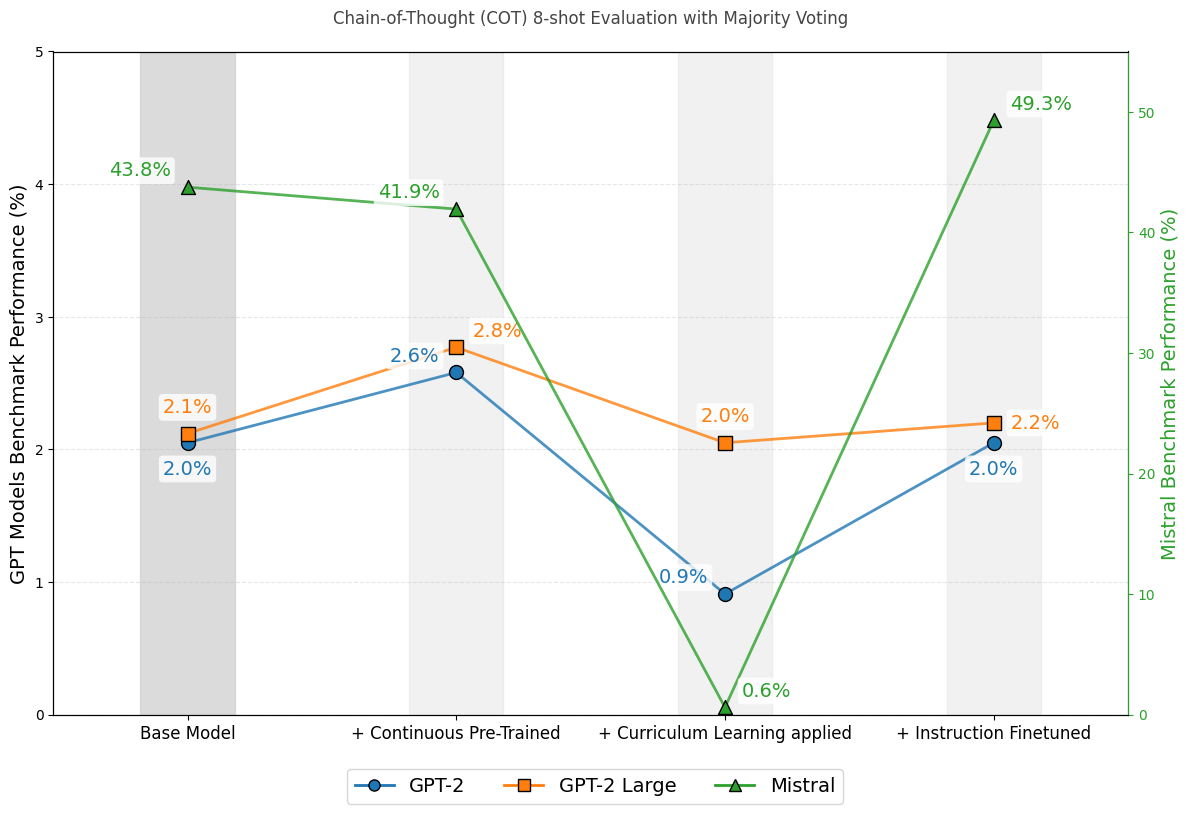

In [38]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D

# Load the data from the Excel file
# Note: Update the path to your actual file location
df = pd.read_excel('/Users/mauricebaier/Documents/Master/4th_master_thesis/_code/math-reasoning-in-language-models/data/Performances.xlsx', engine='openpyxl')

# Ensure the columns are numeric
df['COT 8-shot maj1@8'] = pd.to_numeric(df['COT 8-shot maj1@8'], errors='coerce')

# Extract unique models and training types
models = df['Model'].unique()
training_types = df['Training Type'].unique()

# Define training type positions on x-axis
training_positions = {training: i+1 for i, training in enumerate(training_types)}

# Define colors and markers for models with better visual distinction
model_colors = {
    'GPT-2': '#1f77b4',         # Blue
    'GPT-2 Large': '#ff7f0e',   # Orange
    'Mistral': '#2ca02c'        # Green
}

model_markers = {
    'GPT-2': 'o',         # Circle
    'GPT-2 Large': 's',   # Square
    'Mistral': '^'        # Triangle
}

# Create a figure with a single plot area - slightly taller for legend space at bottom
fig, ax_left = plt.subplots(figsize=(12, 9))

# Create a right y-axis for Mistral
ax_right = ax_left.twinx()

# Set colors for axes
left_color = 'black'      # GPT models
right_color = '#2ca02c'   # Mistral - green

# Style the y-axes
ax_left.tick_params(axis='y', colors=left_color)
ax_left.spines['left'].set_color(left_color)
ax_right.tick_params(axis='y', colors=right_color)
ax_right.spines['right'].set_color(right_color)

# Create wider training "bars" instead of lines
bar_width = 0.35  # Width for bars
for training, x_pos in training_positions.items():
    # Draw wider "bars" for each training position
    # Make the "Raw" section significantly darker
    if training == 'Raw':
        alpha_value = 0.8  # Darker alpha for Base Model (Raw)
    else:
        alpha_value = 0.3  # Keep original alpha for others
        
    ax_left.add_patch(plt.Rectangle((x_pos - bar_width/2, 0), bar_width, 5, 
                              color='lightgray', alpha=alpha_value, zorder=0))

# Prepare data for connecting lines between training types for the same model
model_data = {model: {'x': [], 'y': [], 'training': []} for model in models}

# First, collect all data points
for training, x_pos in training_positions.items():
    # For each model
    for model in models:
        # Get data for this model and training combination
        data_row = df[(df['Model'] == model) & (df['Training Type'] == training)]
        
        if not data_row.empty:
            # Get COT value
            cot = data_row['COT 8-shot maj1@8'].iloc[0]
            
            # Store x and y for connecting lines later
            model_data[model]['x'].append(x_pos)
            model_data[model]['y'].append(cot)
            model_data[model]['training'].append(training)

# Plot data and connect lines for each model
for model, data in model_data.items():
    x_values = data['x']
    y_values = data['y']
    
    # Choose appropriate axis based on model type
    if model == 'Mistral':
        ax = ax_right
    else:
        ax = ax_left
    
    # Draw connecting lines first (beneath points)
    ax.plot(x_values, y_values, color=model_colors[model], linestyle='-', 
            linewidth=2, alpha=0.8, zorder=2)
    
    # Draw points
    ax.scatter(x_values, y_values, 
              color=model_colors[model], marker=model_markers[model], 
              s=100, zorder=3, edgecolors='black', linewidth=1)
    
    # Add small labels for each data point with white background for better readability
    # Use predefined positions to avoid overlaps
    for i, (x, y) in enumerate(zip(x_values, y_values)):
        training = data['training'][i]
        
        # Custom positioning for each data point based on model and training type
        # to avoid overlaps without using external libraries
        if model == 'Mistral':
            if training == 'Raw':
                offset_x, offset_y = -12, 5
                ha, va = 'right', 'bottom'
            elif training == 'Continuous Pre-Trained':
                offset_x, offset_y = -12, 5 
                ha, va = 'right', 'bottom'
            elif training == 'Curriculum Learning':
                offset_x, offset_y = 12, 5
                ha, va = 'left', 'bottom'
            else:  # Instruction Finetuned
                offset_x, offset_y = 12, 5
                ha, va = 'left', 'bottom'
        elif model == 'GPT-2':
            if training == 'Raw':
                offset_x, offset_y = 0, -12
                ha, va = 'center', 'top'
            elif training == 'Continuous Pre-Trained':
                offset_x, offset_y = -12, 5
                ha, va = 'right', 'bottom'
            elif training == 'Curriculum Learning':
                offset_x, offset_y = -12, 5
                ha, va = 'right', 'bottom'
            else:  # Instruction Finetuned
                offset_x, offset_y = 0, -12
                ha, va = 'center', 'top'
        else:  # GPT-2 Large
            if training == 'Raw':
                offset_x, offset_y = 0, 12
                ha, va = 'center', 'bottom'
            elif training == 'Continuous Pre-Trained':
                offset_x, offset_y = 12, 5
                ha, va = 'left', 'bottom'
            elif training == 'Curriculum Learning':
                offset_x, offset_y = 0, 12
                ha, va = 'center', 'bottom'
            else:  # Instruction Finetuned
                offset_x, offset_y = 12, 0
                ha, va = 'left', 'center'
        
        # Create label with white background for better readability
        ax.annotate(
            f"{y:.1f}%", 
            xy=(x, y),
            xytext=(offset_x, offset_y),
            textcoords='offset points',
            ha=ha, va=va,
            fontsize=14,
            color=model_colors[model],
            bbox=dict(boxstyle="round,pad=0.2", fc='white', ec="none", alpha=0.8)
        )

# Set y-axis limits with some padding
ax_left.set_ylim(0, 5)      # GPT models scale (0-5%)
ax_right.set_ylim(0, 55)    # Mistral scale (0-55%)

# Modify x-axis labels: Add "+" in front except for "Raw" and change "Curriculum Learning" to "Curriculum Learning applied"
modified_labels = []
for label in training_positions.keys():
    if label == 'Raw':
        modified_labels.append("Base Model")  # Changed from "Raw" to "Base Model"
    elif label == 'Curriculum Learning':
        modified_labels.append("+ Curriculum Learning applied")
    else:
        modified_labels.append("+ " + label)

# Set x-axis labels
ax_left.set_xticks(list(training_positions.values()))
ax_left.set_xticklabels(modified_labels, fontsize=12, rotation=0, ha='center')
ax_left.set_xlim(0.5, len(training_types) + 0.5)  # Set x-axis limits with padding


# Set y-axis labels
ax_left.set_ylabel('GPT Models Benchmark Performance (%)', fontsize=14, color=left_color)
ax_right.set_ylabel('Mistral Benchmark Performance (%)', fontsize=14, color=right_color)

# Create custom legend with both line and marker
model_legend = []
for model in models:
    model_legend.append(Line2D([0], [0], marker=model_markers[model], color=model_colors[model], 
                      label=model, markersize=8, linestyle='-', linewidth=2,
                      markerfacecolor=model_colors[model], markeredgecolor='black'))

# Add the legend at the bottom of the plot
fig.legend(handles=model_legend, 
          loc='upper center', bbox_to_anchor=(0.5, 0.15),
          ncol=len(models), fontsize=14)


# Add subtitle as the second line in the suptitle with proper spacing
plt.title('Chain-of-Thought (COT) 8-shot Evaluation with Majority Voting', 
          fontsize=12,  # Smaller than the main title
          color='#444444',  # Dark grey
          pad=20)  # Add padding to move it down from the main title

# Add grid lines for readability
ax_left.grid(axis='y', linestyle='--', alpha=0.3)

# Adjust layout - make more room at the bottom for the legend and for the x-axis label
plt.tight_layout()
plt.subplots_adjust(bottom=0.2)  # Increased from 0.15 to 0.2 for the x-axis label

# Save the plot
plt.savefig('benchmark_performance_final.png', dpi=300, bbox_inches='tight')

# Display the plot
plt.show()

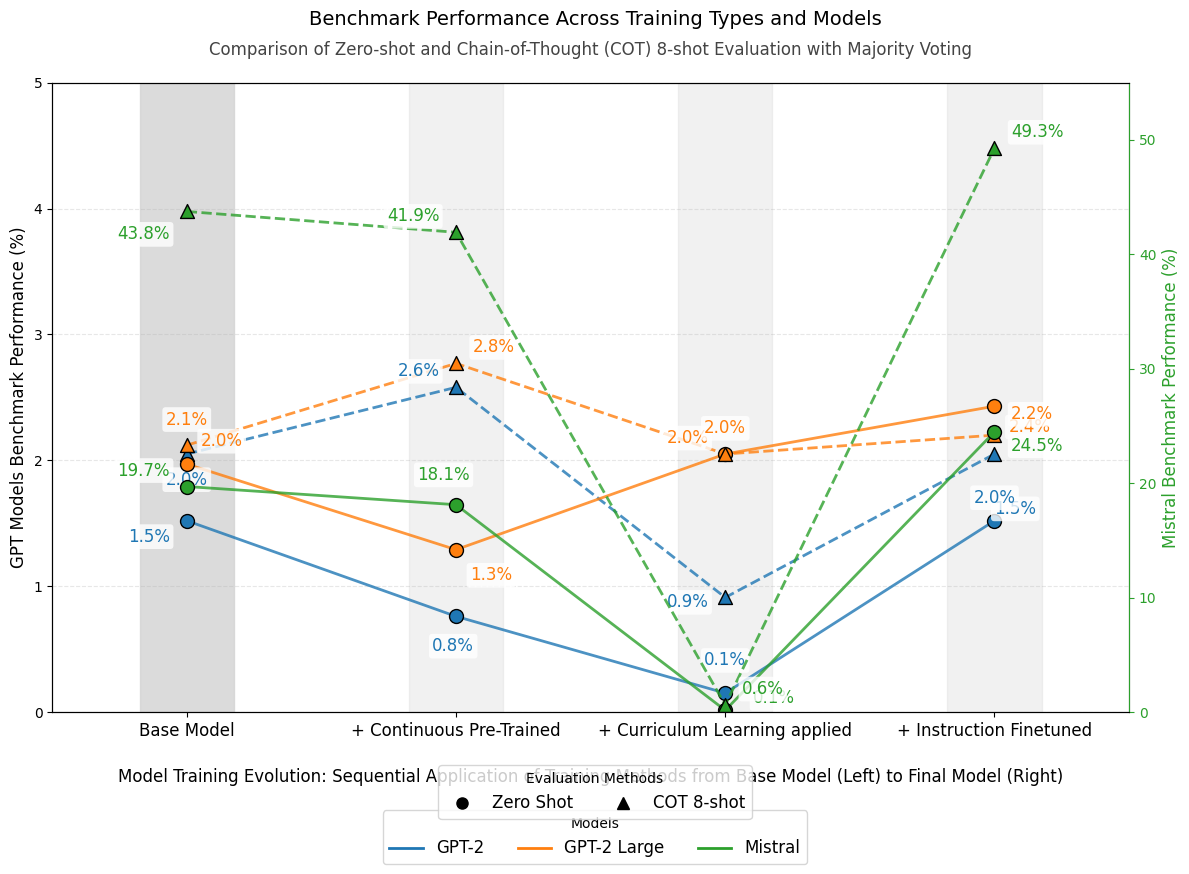

In [39]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D

# Load the data from the Excel file
# Note: Update the path to your actual file location
df = pd.read_excel('/Users/mauricebaier/Documents/Master/4th_master_thesis/_code/math-reasoning-in-language-models/data/Performances.xlsx', engine='openpyxl')

# Ensure the columns are numeric
df['Zero Shot'] = pd.to_numeric(df['Zero Shot'], errors='coerce')
df['COT 8-shot maj1@8'] = pd.to_numeric(df['COT 8-shot maj1@8'], errors='coerce')

# Extract unique models and training types
models = df['Model'].unique()
training_types = df['Training Type'].unique()

# Define training type positions on x-axis
training_positions = {training: i+1 for i, training in enumerate(training_types)}

# Define colors for models with better visual distinction
model_colors = {
    'GPT-2': '#1f77b4',         # Blue
    'GPT-2 Large': '#ff7f0e',   # Orange
    'Mistral': '#2ca02c'        # Green
}

# Define markers for different evaluation methods
eval_markers = {
    'Zero Shot': 'o',     # Circle
    'COT 8-shot': '^'     # Triangle
}

# Create a figure with a single plot area - slightly taller for legend space at bottom
fig, ax_left = plt.subplots(figsize=(12, 9))

# Create a right y-axis for Mistral
ax_right = ax_left.twinx()

# Set colors for axes
left_color = 'black'      # GPT models
right_color = '#2ca02c'   # Mistral - green

# Style the y-axes
ax_left.tick_params(axis='y', colors=left_color)
ax_left.spines['left'].set_color(left_color)
ax_right.tick_params(axis='y', colors=right_color)
ax_right.spines['right'].set_color(right_color)

# Create wider training "bars" instead of lines
bar_width = 0.35  # Width for bars
for training, x_pos in training_positions.items():
    # Draw wider "bars" for each training position
    # Make the "Raw" section significantly darker
    if training == 'Raw':
        alpha_value = 0.8  # Darker alpha for Base Model (Raw)
    else:
        alpha_value = 0.3  # Keep original alpha for others
        
    ax_left.add_patch(plt.Rectangle((x_pos - bar_width/2, 0), bar_width, 5, 
                              color='lightgray', alpha=alpha_value, zorder=0))

# Prepare data for connecting lines between training types for the same model and evaluation type
model_eval_data = {}
for model in models:
    model_eval_data[model] = {
        'Zero Shot': {'x': [], 'y': [], 'training': []},
        'COT 8-shot': {'x': [], 'y': [], 'training': []}
    }

# First, collect all data points
for training, x_pos in training_positions.items():
    # For each model
    for model in models:
        # Get data for this model and training combination
        data_row = df[(df['Model'] == model) & (df['Training Type'] == training)]
        
        if not data_row.empty:
            # Get Zero-shot value
            zero_shot = data_row['Zero Shot'].iloc[0]
            
            # Store x and y for connecting lines later
            model_eval_data[model]['Zero Shot']['x'].append(x_pos)
            model_eval_data[model]['Zero Shot']['y'].append(zero_shot)
            model_eval_data[model]['Zero Shot']['training'].append(training)
            
            # Get COT 8-shot value
            cot = data_row['COT 8-shot maj1@8'].iloc[0]
            
            # Store x and y for connecting lines later
            model_eval_data[model]['COT 8-shot']['x'].append(x_pos)
            model_eval_data[model]['COT 8-shot']['y'].append(cot)
            model_eval_data[model]['COT 8-shot']['training'].append(training)

# Plot data and connect lines for each model and evaluation type
for model in models:
    for eval_type, data in model_eval_data[model].items():
        x_values = data['x']
        y_values = data['y']
        
        # Choose appropriate axis based on model type
        if model == 'Mistral':
            ax = ax_right
        else:
            ax = ax_left
        
        # Draw connecting lines first (beneath points)
        ax.plot(x_values, y_values, color=model_colors[model], linestyle='-' if eval_type == 'Zero Shot' else '--', 
                linewidth=2, alpha=0.8, zorder=2)
        
        # Draw points
        ax.scatter(x_values, y_values, 
                  color=model_colors[model], marker=eval_markers[eval_type], 
                  s=100, zorder=3, edgecolors='black', linewidth=1)
        
        # Add small labels for each data point with white background for better readability
        # Use predefined positions to avoid overlaps
        for i, (x, y) in enumerate(zip(x_values, y_values)):
            training = data['training'][i]
            
            # Custom positioning for each data point based on model, training type, and evaluation method
            # This requires careful adjustment to avoid overlaps
            if model == 'Mistral':
                if eval_type == 'Zero Shot':
                    if training == 'Raw':
                        offset_x, offset_y = -12, 5
                        ha, va = 'right', 'bottom'
                    elif training == 'Continuous Pre-Trained':
                        offset_x, offset_y = 10, 15
                        ha, va = 'right', 'bottom'
                    elif training == 'Curriculum Learning':
                        offset_x, offset_y = 20, 15
                        ha, va = 'left', 'top'
                    else:  # Instruction Finetuned
                        offset_x, offset_y = 12, -10
                        ha, va = 'left', 'center'
                else:  # COT 8-shot
                    if training == 'Raw':
                        offset_x, offset_y = -12, -10
                        ha, va = 'right', 'top'
                    elif training == 'Continuous Pre-Trained':
                        offset_x, offset_y = -12, 5
                        ha, va = 'right', 'bottom'
                    elif training == 'Curriculum Learning':
                        offset_x, offset_y = 12, 5
                        ha, va = 'left', 'bottom'
                    else:  # Instruction Finetuned
                        offset_x, offset_y = 12, 5
                        ha, va = 'left', 'bottom'
            elif model == 'GPT-2':
                if eval_type == 'Zero Shot':
                    if training == 'Raw':
                        offset_x, offset_y = -12, -5
                        ha, va = 'right', 'top'
                    elif training == 'Continuous Pre-Trained':
                        offset_x, offset_y = -2, -15
                        ha, va = 'center', 'top'
                    elif training == 'Curriculum Learning':
                        offset_x, offset_y = 0, 30
                        ha, va = 'center', 'top'
                    else:  # Instruction Finetuned
                        offset_x, offset_y = 15, 15
                        ha, va = 'center', 'top'
                else:  # COT 8-shot
                    if training == 'Raw':
                        offset_x, offset_y = 0, -12
                        ha, va = 'center', 'top'
                    elif training == 'Continuous Pre-Trained':
                        offset_x, offset_y = -12, 5
                        ha, va = 'right', 'bottom'
                    elif training == 'Curriculum Learning':
                        offset_x, offset_y = -12, -10
                        ha, va = 'right', 'bottom'
                    else:  # Instruction Finetuned
                        offset_x, offset_y = 0, -25
                        ha, va = 'center', 'top'
            else:  # GPT-2 Large
                if eval_type == 'Zero Shot':
                    if training == 'Raw':
                        offset_x, offset_y = 10, 10
                        ha, va = 'left', 'bottom'
                    elif training == 'Continuous Pre-Trained':
                        offset_x, offset_y = 10, -12
                        ha, va = 'left', 'top'
                    elif training == 'Curriculum Learning':
                        offset_x, offset_y = -12, 5
                        ha, va = 'right', 'bottom'
                    else:  # Instruction Finetuned
                        offset_x, offset_y = 10, -15
                        ha, va = 'left', 'center'
                else:  # COT 8-shot
                    if training == 'Raw':
                        offset_x, offset_y = 0, 12
                        ha, va = 'center', 'bottom'
                    elif training == 'Continuous Pre-Trained':
                        offset_x, offset_y = 12, 5
                        ha, va = 'left', 'bottom'
                    elif training == 'Curriculum Learning':
                        offset_x, offset_y = 0, 12
                        ha, va = 'center', 'bottom'
                    else:  # Instruction Finetuned
                        offset_x, offset_y = 12, 15
                        ha, va = 'left', 'center'
            
            # Create label with white background for better readability
            ax.annotate(
                f"{y:.1f}%", 
                xy=(x, y),
                xytext=(offset_x, offset_y),
                textcoords='offset points',
                ha=ha, va=va,
                fontsize=12,  # Set font size to 12 as requested
                color=model_colors[model],
                bbox=dict(boxstyle="round,pad=0.2", fc='white', ec="none", alpha=0.8)
            )

# Set y-axis limits with some padding
ax_left.set_ylim(0, 5)      # GPT models scale (0-5%)
ax_right.set_ylim(0, 55)    # Mistral scale (0-55%)

# Modify x-axis labels: Add "+" in front except for "Raw" and change "Curriculum Learning" to "Curriculum Learning applied"
modified_labels = []
for label in training_positions.keys():
    if label == 'Raw':
        modified_labels.append("Base Model")  # Changed from "Raw" to "Base Model"
    elif label == 'Curriculum Learning':
        modified_labels.append("+ Curriculum Learning applied")
    else:
        modified_labels.append("+ " + label)

# Set x-axis labels
ax_left.set_xticks(list(training_positions.values()))
ax_left.set_xticklabels(modified_labels, fontsize=12, rotation=0, ha='center')
ax_left.set_xlim(0.5, len(training_types) + 0.5)  # Set x-axis limits with padding

# Add x-axis label
ax_left.set_xlabel("Model Training Evolution: Sequential Application of Training Methods from Base Model (Left) to Final Model (Right)", 
                  fontsize=12, labelpad=20)

# Set y-axis labels
ax_left.set_ylabel('GPT Models Benchmark Performance (%)', fontsize=12, color=left_color)
ax_right.set_ylabel('Mistral Benchmark Performance (%)', fontsize=12, color=right_color)

# Create custom legend for both models and evaluation types
model_legend = []
for model in models:
    model_legend.append(Line2D([0], [0], color=model_colors[model], 
                      label=model, linewidth=2))

eval_legend = []
for eval_type, marker in eval_markers.items():
    eval_legend.append(Line2D([0], [0], marker=marker, color='black', 
                      label=eval_type, markersize=8, linestyle='None'))

# Add the legends at the bottom of the plot
fig.legend(handles=model_legend, 
          loc='upper center', bbox_to_anchor=(0.5, 0.1),
          ncol=len(models), fontsize=12, title="Models")

fig.legend(handles=eval_legend, 
          loc='upper center', bbox_to_anchor=(0.5, 0.15),
          ncol=len(eval_markers), fontsize=12, title="Evaluation Methods")

# Add title with subtitle as a multi-line title
plt.suptitle('Benchmark Performance Across Training Types and Models', 
             fontsize=14, y=0.98)

# Add subtitle as the second line in the suptitle with proper spacing
plt.title('Comparison of Zero-shot and Chain-of-Thought (COT) 8-shot Evaluation with Majority Voting', 
          fontsize=12,  # Smaller than the main title
          color='#444444',  # Dark grey
          pad=20)  # Add padding to move it down from the main title

# Add grid lines for readability
ax_left.grid(axis='y', linestyle='--', alpha=0.3)

# Adjust layout - make more room at the bottom for the legends and for the x-axis label
plt.tight_layout()
plt.subplots_adjust(bottom=0.2)  # Increased to make room for two legend rows

# Save the plot
plt.savefig('merged_benchmark_performance.png', dpi=300, bbox_inches='tight')

# Display the plot
plt.show()

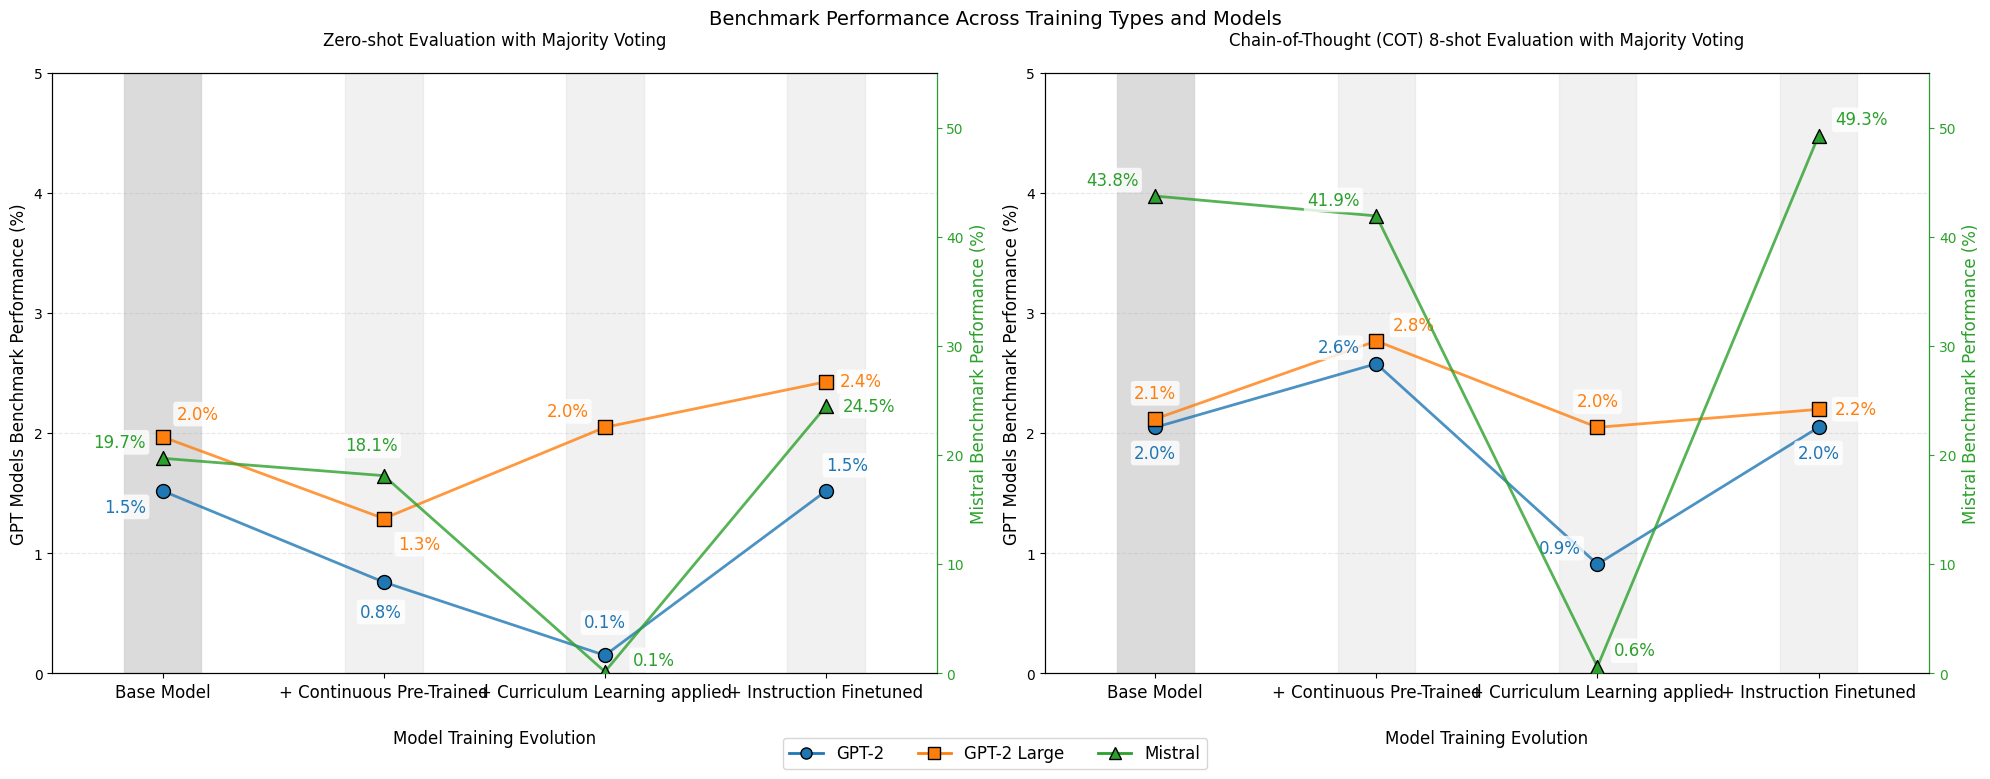

In [31]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D

# Load the data from the Excel file
# Note: Update the path to your actual file location
df = pd.read_excel('/Users/mauricebaier/Documents/Master/4th_master_thesis/_code/math-reasoning-in-language-models/data/Performances.xlsx', engine='openpyxl')

# Ensure the columns are numeric
df['Zero Shot'] = pd.to_numeric(df['Zero Shot'], errors='coerce')
df['COT 8-shot maj1@8'] = pd.to_numeric(df['COT 8-shot maj1@8'], errors='coerce')

# Extract unique models and training types
models = df['Model'].unique()
training_types = df['Training Type'].unique()

# Define training type positions on x-axis
training_positions = {training: i+1 for i, training in enumerate(training_types)}

# Define colors for models with better visual distinction
model_colors = {
    'GPT-2': '#1f77b4',         # Blue
    'GPT-2 Large': '#ff7f0e',   # Orange
    'Mistral': '#2ca02c'        # Green
}

model_markers = {
    'GPT-2': 'o',         # Circle
    'GPT-2 Large': 's',   # Square
    'Mistral': '^'        # Triangle
}

# Create a figure with two subplots side by side
fig, (ax_left_zero, ax_left_cot) = plt.subplots(1, 2, figsize=(20, 8))

# Create right y-axes for Mistral
ax_right_zero = ax_left_zero.twinx()
ax_right_cot = ax_left_cot.twinx()

# Set colors for axes
left_color = 'black'      # GPT models
right_color = '#2ca02c'   # Mistral - green

# Style the y-axes for zero-shot plot
ax_left_zero.tick_params(axis='y', colors=left_color)
ax_left_zero.spines['left'].set_color(left_color)
ax_right_zero.tick_params(axis='y', colors=right_color)
ax_right_zero.spines['right'].set_color(right_color)

# Style the y-axes for COT plot
ax_left_cot.tick_params(axis='y', colors=left_color)
ax_left_cot.spines['left'].set_color(left_color)
ax_right_cot.tick_params(axis='y', colors=right_color)
ax_right_cot.spines['right'].set_color(right_color)

# Create wider training "bars" for zero-shot plot
bar_width = 0.35  # Width for bars
for training, x_pos in training_positions.items():
    # Draw wider "bars" for each training position
    # Make the "Raw" section significantly darker
    if training == 'Raw':
        alpha_value = 0.8  # Darker alpha for Base Model (Raw)
    else:
        alpha_value = 0.3  # Keep original alpha for others
        
    ax_left_zero.add_patch(plt.Rectangle((x_pos - bar_width/2, 0), bar_width, 5, 
                              color='lightgray', alpha=alpha_value, zorder=0))
    
    # Same for COT plot
    ax_left_cot.add_patch(plt.Rectangle((x_pos - bar_width/2, 0), bar_width, 5, 
                              color='lightgray', alpha=alpha_value, zorder=0))

# Prepare data for connecting lines between training types for each model
model_data_zero = {model: {'x': [], 'y': [], 'training': []} for model in models}
model_data_cot = {model: {'x': [], 'y': [], 'training': []} for model in models}

# First, collect all data points
for training, x_pos in training_positions.items():
    # For each model
    for model in models:
        # Get data for this model and training combination
        data_row = df[(df['Model'] == model) & (df['Training Type'] == training)]
        
        if not data_row.empty:
            # Get Zero-shot value
            zero_shot = data_row['Zero Shot'].iloc[0]
            
            # Store x and y for connecting lines later for Zero-shot
            model_data_zero[model]['x'].append(x_pos)
            model_data_zero[model]['y'].append(zero_shot)
            model_data_zero[model]['training'].append(training)
            
            # Get COT 8-shot value
            cot = data_row['COT 8-shot maj1@8'].iloc[0]
            
            # Store x and y for connecting lines later for COT
            model_data_cot[model]['x'].append(x_pos)
            model_data_cot[model]['y'].append(cot)
            model_data_cot[model]['training'].append(training)

# Plot Zero-shot data
for model, data in model_data_zero.items():
    x_values = data['x']
    y_values = data['y']
    
    # Choose appropriate axis based on model type
    if model == 'Mistral':
        ax = ax_right_zero
    else:
        ax = ax_left_zero
    
    # Draw connecting lines first (beneath points)
    ax.plot(x_values, y_values, color=model_colors[model], linestyle='-', 
            linewidth=2, alpha=0.8, zorder=2)
    
    # Draw points
    ax.scatter(x_values, y_values, 
              color=model_colors[model], marker=model_markers[model], 
              s=100, zorder=3, edgecolors='black', linewidth=1)
    
    # Add small labels for each data point with white background for better readability
    for i, (x, y) in enumerate(zip(x_values, y_values)):
        training = data['training'][i]
        
        # Custom positioning for each data point based on model and training type
        # Reusing the Zero-shot positioning from the original code
        if model == 'Mistral':
            if training == 'Raw':
                offset_x, offset_y = -12, 5
                ha, va = 'right', 'bottom'
            elif training == 'Continuous Pre-Trained':
                offset_x, offset_y = 10, 15 
                ha, va = 'right', 'bottom'
            elif training == 'Curriculum Learning':
                offset_x, offset_y = 20, 15  # RIGHT of data point, slightly lower
                ha, va = 'left', 'top'
            else:  # Instruction Finetuned
                offset_x, offset_y = 12, 0  # Just right of data point
                ha, va = 'left', 'center'
        elif model == 'GPT-2':
            if training == 'Raw':
                offset_x, offset_y = -12, -5
                ha, va = 'right', 'top'
            elif training == 'Continuous Pre-Trained':
                offset_x, offset_y = -2, -15
                ha, va = 'center', 'top'
            elif training == 'Curriculum Learning':
                offset_x, offset_y = 0, 30  # ABOVE data point with MORE distance
                ha, va = 'center', 'top'
            else:  # Instruction Finetuned
                offset_x, offset_y = 15, 25  # Just above data point
                ha, va = 'center', 'top'
        else:  # GPT-2 Large
            if training == 'Raw':
                offset_x, offset_y = 10, 10
                ha, va = 'left', 'bottom'
            elif training == 'Continuous Pre-Trained':
                offset_x, offset_y = 10, -12
                ha, va = 'left', 'top'
            elif training == 'Curriculum Learning':
                offset_x, offset_y = -12, 5  # LEFT and ABOVE data point
                ha, va = 'right', 'bottom'
            else:  # Instruction Finetuned
                offset_x, offset_y = 10, 0  # RIGHT of data point
                ha, va = 'left', 'center'
        
        # Create label with white background for better readability
        ax.annotate(
            f"{y:.1f}%", 
            xy=(x, y),
            xytext=(offset_x, offset_y),
            textcoords='offset points',
            ha=ha, va=va,
            fontsize=12,  # Font size 12 as requested
            color=model_colors[model],
            bbox=dict(boxstyle="round,pad=0.2", fc='white', ec="none", alpha=0.8)
        )

# Plot COT data
for model, data in model_data_cot.items():
    x_values = data['x']
    y_values = data['y']
    
    # Choose appropriate axis based on model type
    if model == 'Mistral':
        ax = ax_right_cot
    else:
        ax = ax_left_cot
    
    # Draw connecting lines first (beneath points)
    ax.plot(x_values, y_values, color=model_colors[model], linestyle='-', 
            linewidth=2, alpha=0.8, zorder=2)
    
    # Draw points
    ax.scatter(x_values, y_values, 
              color=model_colors[model], marker=model_markers[model], 
              s=100, zorder=3, edgecolors='black', linewidth=1)
    
    # Add small labels for each data point with white background for better readability
    for i, (x, y) in enumerate(zip(x_values, y_values)):
        training = data['training'][i]
        
        # Custom positioning for each data point based on model and training type
        # Reusing the COT positioning from the original code
        if model == 'Mistral':
            if training == 'Raw':
                offset_x, offset_y = -12, 5
                ha, va = 'right', 'bottom'
            elif training == 'Continuous Pre-Trained':
                offset_x, offset_y = -12, 5 
                ha, va = 'right', 'bottom'
            elif training == 'Curriculum Learning':
                offset_x, offset_y = 12, 5
                ha, va = 'left', 'bottom'
            else:  # Instruction Finetuned
                offset_x, offset_y = 12, 5
                ha, va = 'left', 'bottom'
        elif model == 'GPT-2':
            if training == 'Raw':
                offset_x, offset_y = 0, -12
                ha, va = 'center', 'top'
            elif training == 'Continuous Pre-Trained':
                offset_x, offset_y = -12, 5
                ha, va = 'right', 'bottom'
            elif training == 'Curriculum Learning':
                offset_x, offset_y = -12, 5
                ha, va = 'right', 'bottom'
            else:  # Instruction Finetuned
                offset_x, offset_y = 0, -12
                ha, va = 'center', 'top'
        else:  # GPT-2 Large
            if training == 'Raw':
                offset_x, offset_y = 0, 12
                ha, va = 'center', 'bottom'
            elif training == 'Continuous Pre-Trained':
                offset_x, offset_y = 12, 5
                ha, va = 'left', 'bottom'
            elif training == 'Curriculum Learning':
                offset_x, offset_y = 0, 12
                ha, va = 'center', 'bottom'
            else:  # Instruction Finetuned
                offset_x, offset_y = 12, 0
                ha, va = 'left', 'center'
        
        # Create label with white background for better readability
        ax.annotate(
            f"{y:.1f}%", 
            xy=(x, y),
            xytext=(offset_x, offset_y),
            textcoords='offset points',
            ha=ha, va=va,
            fontsize=12,  # Font size 12 as requested
            color=model_colors[model],
            bbox=dict(boxstyle="round,pad=0.2", fc='white', ec="none", alpha=0.8)
        )

# Set y-axis limits for both plots
ax_left_zero.set_ylim(0, 5)      # GPT models scale (0-5%)
ax_right_zero.set_ylim(0, 55)    # Mistral scale (0-55%)
ax_left_cot.set_ylim(0, 5)       # GPT models scale (0-5%)
ax_right_cot.set_ylim(0, 55)     # Mistral scale (0-55%)

# Modify x-axis labels for both plots
modified_labels = []
for label in training_positions.keys():
    if label == 'Raw':
        modified_labels.append("Base Model")  # Changed from "Raw" to "Base Model"
    elif label == 'Curriculum Learning':
        modified_labels.append("+ Curriculum Learning applied")
    else:
        modified_labels.append("+ " + label)

# Set x-axis labels for both plots
for ax in [ax_left_zero, ax_left_cot]:
    ax.set_xticks(list(training_positions.values()))
    ax.set_xticklabels(modified_labels, fontsize=12, rotation=0, ha='center')
    ax.set_xlim(0.5, len(training_types) + 0.5)  # Set x-axis limits with padding

# Add x-axis labels for both plots
ax_left_zero.set_xlabel("Model Training Evolution", fontsize=12, labelpad=20)
ax_left_cot.set_xlabel("Model Training Evolution", fontsize=12, labelpad=20)

# Set y-axis labels
ax_left_zero.set_ylabel('GPT Models Benchmark Performance (%)', fontsize=12, color=left_color)
ax_right_zero.set_ylabel('Mistral Benchmark Performance (%)', fontsize=12, color=right_color)
ax_left_cot.set_ylabel('GPT Models Benchmark Performance (%)', fontsize=12, color=left_color)
ax_right_cot.set_ylabel('Mistral Benchmark Performance (%)', fontsize=12, color=right_color)

# Add subtitles for each plot
ax_left_zero.set_title('Zero-shot Evaluation with Majority Voting', fontsize=12, pad=20)
ax_left_cot.set_title('Chain-of-Thought (COT) 8-shot Evaluation with Majority Voting', fontsize=12, pad=20)

# Add grid lines for readability
ax_left_zero.grid(axis='y', linestyle='--', alpha=0.3)
ax_left_cot.grid(axis='y', linestyle='--', alpha=0.3)

# Create custom legend for the models
model_legend = []
for model in models:
    model_legend.append(Line2D([0], [0], marker=model_markers[model], color=model_colors[model], 
                      label=model, markersize=8, linestyle='-', linewidth=2,
                      markerfacecolor=model_colors[model], markeredgecolor='black'))

# Add the legend at the bottom center of the figure
fig.legend(handles=model_legend, 
          loc='lower center', bbox_to_anchor=(0.5, 0.02),
          ncol=len(models), fontsize=12)

# Add main title for the entire figure
fig.suptitle('Benchmark Performance Across Training Types and Models', 
             fontsize=14, y=0.98)

# Adjust layout
plt.tight_layout()
plt.subplots_adjust(bottom=0.15, top=0.9)  # Make room for the legend at the bottom and title at the top

# Save the plot
plt.savefig('side_by_side_benchmark_performance.png', dpi=300, bbox_inches='tight')

# Display the plot
plt.show()

/var/folders/yn/2tfz0n9x7m3dkwb69m05y8lw0000gn/T/ipykernel_40990/1174065090.py:60: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.add_patch(Polygon(lower_points, closed=True, fill=True, color='white', zorder=5,
/var/folders/yn/2tfz0n9x7m3dkwb69m05y8lw0000gn/T/ipykernel_40990/1174065090.py:70: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.add_patch(Polygon(upper_points, closed=True, fill=True, color='white', zorder=5,


AttributeError: 'Spine' object has no attribute 'copy'

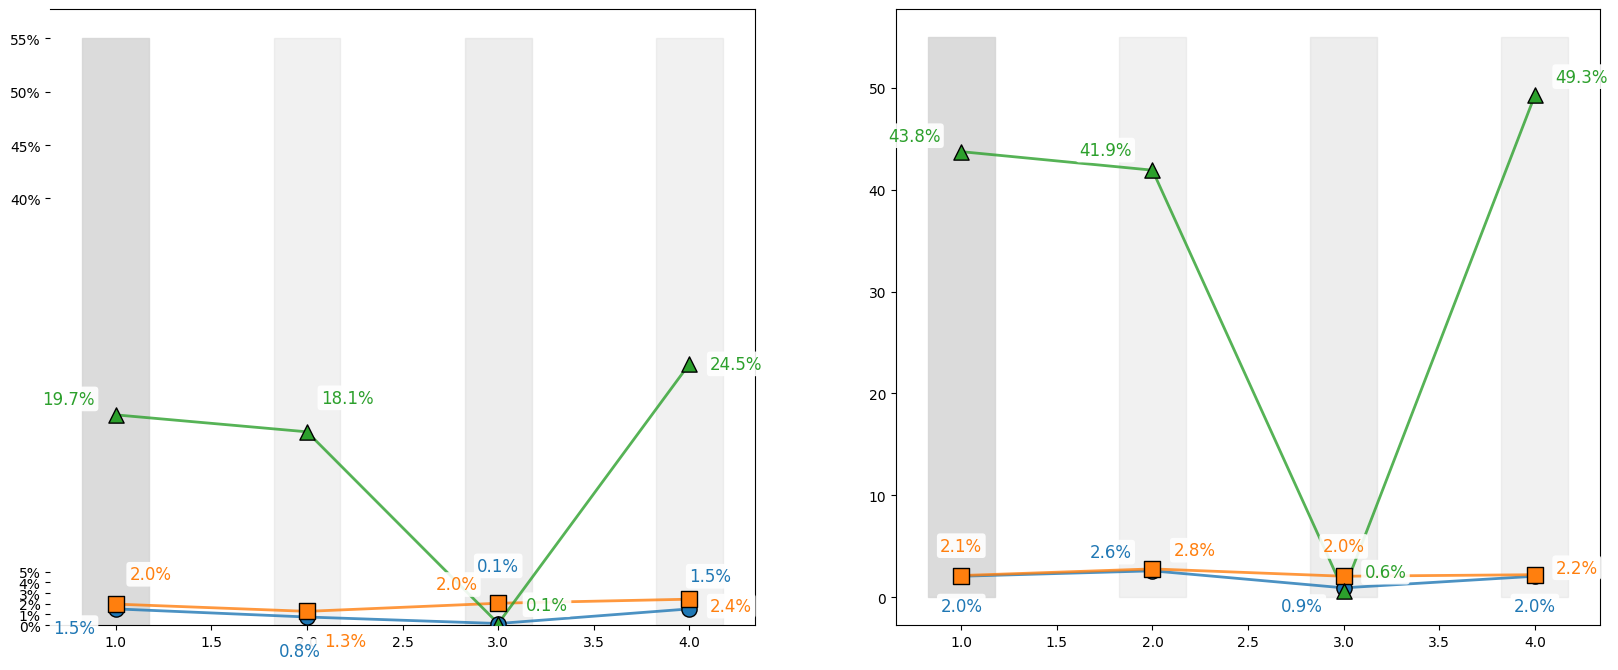

In [32]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D
from matplotlib.patches import Rectangle, Polygon

# Load the data from the Excel file
# Note: Update the path to your actual file location
df = pd.read_excel('/Users/mauricebaier/Documents/Master/4th_master_thesis/_code/math-reasoning-in-language-models/data/Performances.xlsx', engine='openpyxl')

# Ensure the columns are numeric
df['Zero Shot'] = pd.to_numeric(df['Zero Shot'], errors='coerce')
df['COT 8-shot maj1@8'] = pd.to_numeric(df['COT 8-shot maj1@8'], errors='coerce')

# Extract unique models and training types
models = df['Model'].unique()
training_types = df['Training Type'].unique()

# Define training type positions on x-axis
training_positions = {training: i+1 for i, training in enumerate(training_types)}

# Define colors for models with better visual distinction
model_colors = {
    'GPT-2': '#1f77b4',         # Blue
    'GPT-2 Large': '#ff7f0e',   # Orange
    'Mistral': '#2ca02c'        # Green
}

model_markers = {
    'GPT-2': 'o',         # Circle
    'GPT-2 Large': 's',   # Square
    'Mistral': '^'        # Triangle
}

# Create a figure with two subplots side by side
fig, (ax_zero, ax_cot) = plt.subplots(1, 2, figsize=(20, 8))

# Function to create an axis break
def add_axis_break(ax, ylim_lower=(0, 5), ylim_upper=(40, 55), break_width=0.01, break_height=0.02):
    # Calculate the data-to-axis ratio
    data_width = ax.get_xlim()[1] - ax.get_xlim()[0]
    data_height = ylim_upper[1] - ylim_lower[0]
    
    # Add a diagonal line to indicate the break
    break_x = 0.02 * data_width  # Offset from y-axis
    break_y_bottom = ylim_lower[1]
    break_y_top = ylim_upper[0]
    
    # Draw diagonal lines to indicate the break
    diag_width = break_width * data_width
    diag_height = break_height * data_height
    
    # Lower diagonal
    lower_points = [
        (break_x - diag_width/2, break_y_bottom + diag_height/2),
        (break_x + diag_width/2, break_y_bottom - diag_height/2),
        (break_x + diag_width*1.5, break_y_bottom + diag_height/2),
        (break_x - diag_width/2, break_y_bottom + diag_height*1.5)
    ]
    ax.add_patch(Polygon(lower_points, closed=True, fill=True, color='white', zorder=5, 
                         edgecolor='black', linewidth=0.5))
    
    # Upper diagonal
    upper_points = [
        (break_x - diag_width/2, break_y_top + diag_height/2),
        (break_x + diag_width/2, break_y_top - diag_height/2),
        (break_x + diag_width*1.5, break_y_top + diag_height/2),
        (break_x - diag_width/2, break_y_top + diag_height*1.5)
    ]
    ax.add_patch(Polygon(upper_points, closed=True, fill=True, color='white', zorder=5, 
                         edgecolor='black', linewidth=0.5))
    
    # Configure the y-axis
    ax.set_ylim(ylim_upper[1])
    
    # Add two separate y-axes: one for the bottom part and one for the top part
    ax.spines['left'].set_visible(False)  # Hide the original y-axis
    
    # Create custom tick positions and labels
    lower_ticks = np.linspace(ylim_lower[0], ylim_lower[1], 6)
    upper_ticks = np.linspace(ylim_upper[0], ylim_upper[1], 4)
    all_ticks = np.concatenate([lower_ticks, upper_ticks])
    
    # Add ticks and grid lines
    ax.set_yticks(all_ticks)
    ax.set_yticklabels([f"{x:.0f}%" for x in all_ticks])
    
    # Hide the ticks in the break area
    break_ticks = [t for t in ax.get_yticks() if t > ylim_lower[1] and t < ylim_upper[0]]
    for tick in break_ticks:
        idx = np.where(ax.get_yticks() == tick)[0][0]
        ax.get_yticklabels()[idx].set_visible(False)
    
    # Add new y-axis spines for both segments
    # Lower segment
    low_spine = ax.spines['left'].copy()
    low_spine.set_bounds(ylim_lower[0], ylim_lower[1])
    low_spine.set_visible(True)
    ax.spines['left'] = low_spine
    
    # Upper segment
    high_spine = ax.spines['left'].copy()
    high_spine.set_bounds(ylim_upper[0], ylim_upper[1])
    high_spine.set_position(('outward', 0))
    high_spine.set_visible(True)
    ax.spines['left2'] = high_spine

# Create wider training "bars" for both plots
bar_width = 0.35  # Width for bars
for training, x_pos in training_positions.items():
    # Use alternating gray shades for better visual separation
    if training == 'Raw':
        alpha_value = 0.8  # Darker alpha for Base Model (Raw)
    else:
        # Alternate between lighter shades for other training types
        if (list(training_positions.keys()).index(training) % 2) == 1:
            alpha_value = 0.3
        else:
            alpha_value = 0.4
        
    ax_zero.add_patch(plt.Rectangle((x_pos - bar_width/2, 0), bar_width, 55, 
                              color='lightgray', alpha=alpha_value, zorder=0))
    
    # Same for COT plot
    ax_cot.add_patch(plt.Rectangle((x_pos - bar_width/2, 0), bar_width, 55, 
                              color='lightgray', alpha=alpha_value, zorder=0))

# Prepare data for connecting lines between training types for each model
model_data_zero = {model: {'x': [], 'y': [], 'training': []} for model in models}
model_data_cot = {model: {'x': [], 'y': [], 'training': []} for model in models}

# First, collect all data points
for training, x_pos in training_positions.items():
    # For each model
    for model in models:
        # Get data for this model and training combination
        data_row = df[(df['Model'] == model) & (df['Training Type'] == training)]
        
        if not data_row.empty:
            # Get Zero-shot value
            zero_shot = data_row['Zero Shot'].iloc[0]
            
            # Store x and y for connecting lines later for Zero-shot
            model_data_zero[model]['x'].append(x_pos)
            model_data_zero[model]['y'].append(zero_shot)
            model_data_zero[model]['training'].append(training)
            
            # Get COT 8-shot value
            cot = data_row['COT 8-shot maj1@8'].iloc[0]
            
            # Store x and y for connecting lines later for COT
            model_data_cot[model]['x'].append(x_pos)
            model_data_cot[model]['y'].append(cot)
            model_data_cot[model]['training'].append(training)

# Plot Zero-shot data
for model, data in model_data_zero.items():
    x_values = data['x']
    y_values = data['y']
    
    # Draw connecting lines first (beneath points)
    ax_zero.plot(x_values, y_values, color=model_colors[model], linestyle='-', 
            linewidth=2, alpha=0.8, zorder=2)
    
    # Draw points with slightly larger markers
    ax_zero.scatter(x_values, y_values, 
              color=model_colors[model], marker=model_markers[model], 
              s=120, zorder=3, edgecolors='black', linewidth=1)
    
    # Add small labels for each data point with white background for better readability
    for i, (x, y) in enumerate(zip(x_values, y_values)):
        training = data['training'][i]
        
        # Custom positioning with adjustments to reduce overlaps
        if model == 'Mistral':
            if training == 'Raw':
                offset_x, offset_y = -15, 5
                ha, va = 'right', 'bottom'
            elif training == 'Continuous Pre-Trained':
                offset_x, offset_y = 10, 18
                ha, va = 'left', 'bottom'
            elif training == 'Curriculum Learning':
                offset_x, offset_y = 20, 20
                ha, va = 'left', 'top'
            else:  # Instruction Finetuned
                offset_x, offset_y = 15, 0
                ha, va = 'left', 'center'
        elif model == 'GPT-2':
            if training == 'Raw':
                offset_x, offset_y = -15, -7
                ha, va = 'right', 'top'
            elif training == 'Continuous Pre-Trained':
                offset_x, offset_y = -5, -18
                ha, va = 'center', 'top'
            elif training == 'Curriculum Learning':
                offset_x, offset_y = 0, 35
                ha, va = 'center', 'bottom'
            else:  # Instruction Finetuned
                offset_x, offset_y = 15, 30
                ha, va = 'center', 'top'
        else:  # GPT-2 Large
            if training == 'Raw':
                offset_x, offset_y = 10, 15
                ha, va = 'left', 'bottom'
            elif training == 'Continuous Pre-Trained':
                offset_x, offset_y = 12, -15
                ha, va = 'left', 'top'
            elif training == 'Curriculum Learning':
                offset_x, offset_y = -15, 7
                ha, va = 'right', 'bottom'
            else:  # Instruction Finetuned
                offset_x, offset_y = 15, -5
                ha, va = 'left', 'center'
        
        # Create label with white background
        ax_zero.annotate(
            f"{y:.1f}%", 
            xy=(x, y),
            xytext=(offset_x, offset_y),
            textcoords='offset points',
            ha=ha, va=va,
            fontsize=12,
            color=model_colors[model],
            bbox=dict(boxstyle="round,pad=0.2", fc='white', ec="none", alpha=0.9)
        )

# Plot COT data
for model, data in model_data_cot.items():
    x_values = data['x']
    y_values = data['y']
    
    # Draw connecting lines first (beneath points)
    ax_cot.plot(x_values, y_values, color=model_colors[model], linestyle='-', 
            linewidth=2, alpha=0.8, zorder=2)
    
    # Draw points with slightly larger markers
    ax_cot.scatter(x_values, y_values, 
              color=model_colors[model], marker=model_markers[model], 
              s=120, zorder=3, edgecolors='black', linewidth=1)
    
    # Add small labels for each data point with white background for better readability
    for i, (x, y) in enumerate(zip(x_values, y_values)):
        training = data['training'][i]
        
        # Custom positioning with adjustments to reduce overlaps
        if model == 'Mistral':
            if training == 'Raw':
                offset_x, offset_y = -15, 5
                ha, va = 'right', 'bottom'
            elif training == 'Continuous Pre-Trained':
                offset_x, offset_y = -15, 8
                ha, va = 'right', 'bottom'
            elif training == 'Curriculum Learning':
                offset_x, offset_y = 15, 7
                ha, va = 'left', 'bottom'
            else:  # Instruction Finetuned
                offset_x, offset_y = 15, 7
                ha, va = 'left', 'bottom'
        elif model == 'GPT-2':
            if training == 'Raw':
                offset_x, offset_y = 0, -15
                ha, va = 'center', 'top'
            elif training == 'Continuous Pre-Trained':
                offset_x, offset_y = -15, 7
                ha, va = 'right', 'bottom'
            elif training == 'Curriculum Learning':
                offset_x, offset_y = -15, -7
                ha, va = 'right', 'top'
            else:  # Instruction Finetuned
                offset_x, offset_y = 0, -15
                ha, va = 'center', 'top'
        else:  # GPT-2 Large
            if training == 'Raw':
                offset_x, offset_y = 0, 15
                ha, va = 'center', 'bottom'
            elif training == 'Continuous Pre-Trained':
                offset_x, offset_y = 15, 7
                ha, va = 'left', 'bottom'
            elif training == 'Curriculum Learning':
                offset_x, offset_y = 0, 15
                ha, va = 'center', 'bottom'
            else:  # Instruction Finetuned
                offset_x, offset_y = 15, 5
                ha, va = 'left', 'center'
        
        # Create label with white background
        ax_cot.annotate(
            f"{y:.1f}%", 
            xy=(x, y),
            xytext=(offset_x, offset_y),
            textcoords='offset points',
            ha=ha, va=va,
            fontsize=12,
            color=model_colors[model],
            bbox=dict(boxstyle="round,pad=0.2", fc='white', ec="none", alpha=0.9)
        )

# Add axis breaks to both plots to unify the y-axes
add_axis_break(ax_zero, ylim_lower=(0, 5), ylim_upper=(40, 55))
add_axis_break(ax_cot, ylim_lower=(0, 5), ylim_upper=(40, 55))

# Set axes limits
ax_zero.set_ylim(0, 55)
ax_cot.set_ylim(0, 55)

# Modify x-axis labels for both plots
modified_labels = []
for label in training_positions.keys():
    if label == 'Raw':
        modified_labels.append("Base Model")
    elif label == 'Curriculum Learning':
        modified_labels.append("+ Curriculum Learning applied")
    else:
        modified_labels.append("+ " + label)

# Set x-axis labels for both plots
for ax in [ax_zero, ax_cot]:
    ax.set_xticks(list(training_positions.values()))
    ax.set_xticklabels(modified_labels, fontsize=12, rotation=0, ha='center')
    ax.set_xlim(0.5, len(training_types) + 0.5)

# Add x-axis label for both plots (more concise version)
ax_zero.set_xlabel("Model Training Evolution", fontsize=12, labelpad=20)
ax_cot.set_xlabel("Model Training Evolution", fontsize=12, labelpad=20)

# Set y-axis labels (more concise version)
ax_zero.set_ylabel('Benchmark Performance (%)', fontsize=12)
# No need for y-axis label on right plot since they're unified

# Add subtitles for each plot
ax_zero.set_title('Zero-shot Evaluation with Majority Voting', fontsize=13, pad=20)
ax_cot.set_title('Chain-of-Thought (COT) 8-shot Evaluation with Majority Voting', fontsize=13, pad=20)

# Add grid lines for readability (horizontal only)
ax_zero.grid(axis='y', linestyle='--', alpha=0.3)
ax_cot.grid(axis='y', linestyle='--', alpha=0.3)

# Create custom legend for the models
model_legend = []
for model in models:
    model_legend.append(Line2D([0], [0], marker=model_markers[model], color=model_colors[model], 
                      label=model, markersize=10, linestyle='-', linewidth=2,
                      markerfacecolor=model_colors[model], markeredgecolor='black'))

# Add the legend at the bottom center of the figure with a border
legend = fig.legend(handles=model_legend, 
          loc='lower center', bbox_to_anchor=(0.5, 0.02),
          ncol=len(models), fontsize=12, frameon=True, framealpha=0.9)
legend.get_frame().set_linewidth(0.5)

# Add main title for the entire figure with an underline
main_title = fig.suptitle('Benchmark Performance Across Training Types and Models', 
             fontsize=15, y=0.98, fontweight='bold')

# Add a thin horizontal line under the main title
fig.text(0.125, 0.94, '_'*120, color='gray')

# Adjust layout
plt.tight_layout()
plt.subplots_adjust(bottom=0.15, top=0.88, wspace=0.15)  # Adjusted for title and legend

# Save the plot
plt.savefig('improved_side_by_side_performance.png', dpi=300, bbox_inches='tight')

# Display the plot
plt.show()